In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer, StandardScaler

from dfply import *

import tensorflow as tf
from tensorflow.keras import  regularizers, callbacks
from tensorflow.python.keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, Concatenate, LeakyReLU, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# tf-explain for visual explanations
from tf_explain.core.gradients_inputs import GradientsInputs

import pydot, pyreadr

from scipy.stats import norm
from scipy import stats
import lime
from lime.lime_tabular import LimeTabularExplainer
from interpret.blackbox import LimeTabular
from interpret import show

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
# --- Configuration ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Data preprocessing
Two functions are created here. "categorize_by_group" categorises the hypertrophic response of particpants into "High_responder", "Average responder", and "No_responders". 
"process_metadata" would load the individual RDS file for each study, add the sequencing depth and the columns needed for modelling

In [3]:

def categorize_by_group(df):
    """
    Categorizes participants into response levels within each 'condition' and 'volume' group.
    Adds a new column 'category' to the DataFrame.
    
    - High_responder: pct_muscle_change >= 90th percentile of the group
    - No_responder: pct_muscle_change < 1
    - Average_responder: all others
    """
    def label_group(group):
        high_threshold = np.percentile(group["pct_muscle_change"], 90)
        conditions = [
            group["pct_muscle_change"] >= high_threshold,
            group["pct_muscle_change"] < 1
        ]
        choices = ["High_responder", "No_responder"]
        group["category"] = np.select(conditions, choices, default="Average_responder")
        return group

    return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)



In [4]:
# A function to load the metadata of the different studies and the required columns
def process_metadata(filepath,  sequencing_depth):
    """
    Load and process COPD metadata from an RDS file.

    Parameters:
        filepath (str): Path to the RDS file.
        category_function (callable): Function to categorize participants based on muscle change.
        sequencing_depth (float or int): Value to assign as sequencing depth for all samples.

    Returns:
        pd.DataFrame: Processed COPD metadata.
    """
    # Load the RDS file
    data = pyreadr.read_r(filepath)[None]

    # apply the  categorize_by_group functiomn
    data = categorize_by_group(data)

    # Add sequencing depth as a new column
    # This is calculated from the sequencing data
    data["sequencing_depth"] = sequencing_depth

    # Select relevant columns
    selected_columns = [
        "study", "participant", "sex", "seq_sample_id", "age", "BMI",
        "pct_muscle_change",  "category", "volume",
        "condition", "sequencing_depth"
    ]
    return data[selected_columns]


## COPD METADATA

In [5]:
# COPD metadata
copd_metadata = process_metadata("./COPD/copd_metadata.RDS", 1.2)
copd_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_22352\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,copd,FP102,female,X102PreExcVLR12,65.8,36.6,-1.98,No_responder,3.0,RM30,1.2
1,copd,FP102,female,X102PreExcVLR12,65.8,36.6,17.24,High_responder,3.0,RM10,1.2
2,copd,FP103,male,X103PreExcVLR23,70.9,28.5,6.81,Average_responder,3.0,RM10,1.2
3,copd,FP103,male,X103PreExcVLR23,70.9,28.5,14.01,Average_responder,3.0,RM30,1.2
4,copd,FP105,female,X105PreExcVLR38,67.0,24.6,13.87,Average_responder,3.0,RM30,1.2
...,...,...,...,...,...,...,...,...,...,...,...
98,copd,FP246,female,X246PreExcVLR518,64.3,22.4,6.10,Average_responder,3.0,RM10,1.2
99,copd,FP246,female,X246PreExcVLL519,64.3,22.4,3.88,Average_responder,3.0,RM30,1.2
100,copd,FP249,male,X249PreExcVLL529,63.6,22.0,4.32,Average_responder,3.0,RM30,1.2
101,copd,FP249,male,X249PreExcVLL529,63.6,22.0,3.34,Average_responder,3.0,RM10,1.2


<Axes: xlabel='category', ylabel='count'>

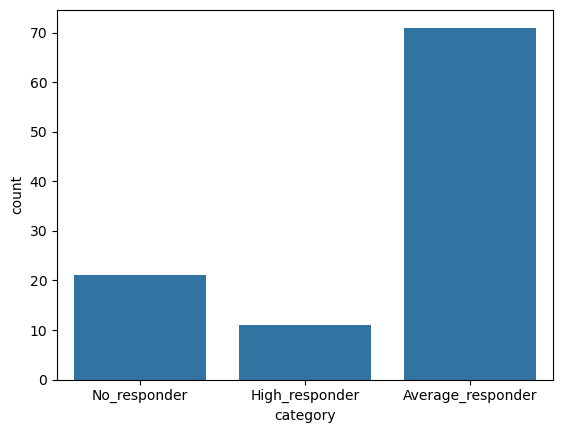

In [6]:
sns.countplot(x =copd_metadata["category"])

(array([ 1.,  0.,  4., 12., 10., 31., 18., 13., 10.,  4.]),
 array([-16.38 , -12.363,  -8.346,  -4.329,  -0.312,   3.705,   7.722,
         11.739,  15.756,  19.773,  23.79 ]),
 <BarContainer object of 10 artists>)

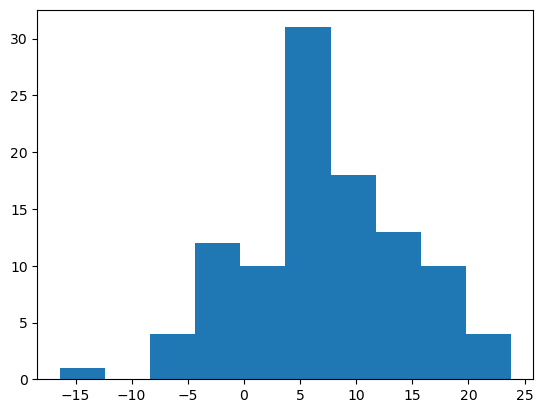

In [7]:
plt.hist(copd_metadata["pct_muscle_change"])

## Contratrain metadata

In [8]:
contratrain_metadata = process_metadata("./ContraTrain/Contratrain_metadata.RDS", 4.03)

contratrain_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_22352\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,ct,FP1,female,X1.subj1sample1,21.0,28.6,3.78,Average_responder,0.0,RM10,4.03
1,ct,FP1,female,X2.subj1sample6,21.0,28.6,12.98,Average_responder,3.0,RM10,4.03
2,ct,FP2,male,X43.subj2sample4,24.0,31.2,9.88,Average_responder,3.0,RM10,4.03
3,ct,FP2,male,X44.subj2sample6,24.0,31.2,9.23,Average_responder,6.0,RM10,4.03
4,ct,FP3,female,X75.subj3sample5,23.0,22.5,17.03,Average_responder,6.0,RM10,4.03
...,...,...,...,...,...,...,...,...,...,...,...
59,ct,FP43,female,X108.subj43sample3,24.0,40.1,-1.62,No_responder,0.0,RM10,4.03
60,ct,FP44,female,X113.subj44sample4,30.0,24.6,10.30,Average_responder,3.0,RM10,4.03
61,ct,FP45,female,X116.subj45sample4,20.0,26.2,2.46,Average_responder,3.0,RM10,4.03
62,ct,FP46,female,X121.subj46sample7,22.0,22.9,3.90,Average_responder,0.0,RM10,4.03


<Axes: xlabel='category', ylabel='count'>

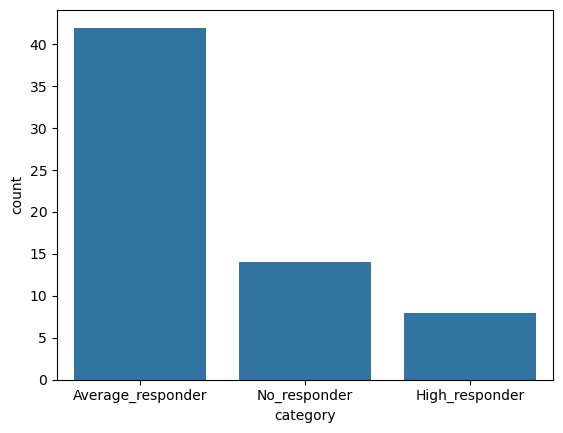

In [9]:
sns.countplot(x =contratrain_metadata["category"])

(array([ 4., 16., 13., 12., 13.,  2.,  3.,  0.,  0.,  1.]),
 array([-7.17 , -2.268,  2.634,  7.536, 12.438, 17.34 , 22.242, 27.144,
        32.046, 36.948, 41.85 ]),
 <BarContainer object of 10 artists>)

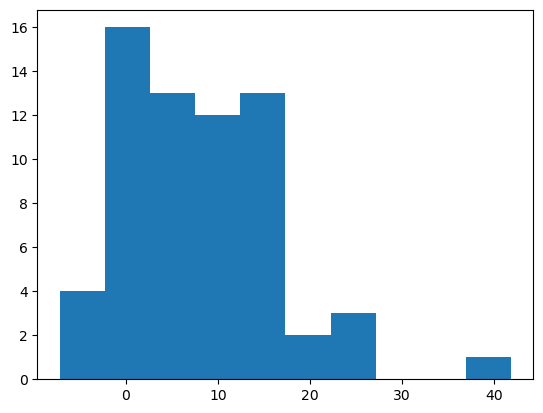

In [10]:
plt.hist(contratrain_metadata["pct_muscle_change"])

In [11]:
AO_metadata = process_metadata("./Alpha_Omega/Alpha_Omega_metadata.RDS", 2.35)
AO_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_22352\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,Alpha/Omega,516,male,s104,46.0,29.0,18.75,Average_responder,3.0,RM10,2.35
1,Alpha/Omega,517,male,s112,53.0,30.3,12.66,Average_responder,3.0,RM10,2.35
2,Alpha/Omega,503,male,s13,46.0,25.3,50.37,High_responder,3.0,RM10,2.35
3,Alpha/Omega,520,male,s130,58.0,29.9,8.62,Average_responder,3.0,RM10,2.35
4,Alpha/Omega,521,female,s136,48.0,18.4,33.69,High_responder,3.0,RM10,2.35
...,...,...,...,...,...,...,...,...,...,...,...
161,Alpha/Omega,683,female,s874,35.0,29.3,2.60,Average_responder,3.0,RM30,2.35
162,Alpha/Omega,684,female,s875,48.0,31.6,24.79,Average_responder,3.0,RM30,2.35
163,Alpha/Omega,692,male,s883,58.0,23.9,43.34,High_responder,3.0,RM30,2.35
164,Alpha/Omega,693,female,s891,54.0,21.8,21.82,Average_responder,3.0,RM30,2.35


<Axes: xlabel='category', ylabel='count'>

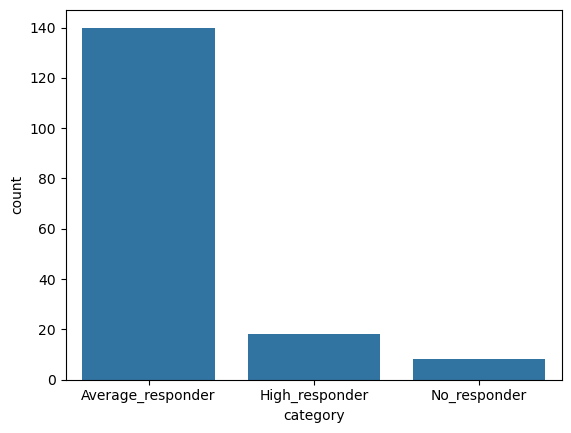

In [12]:
sns.countplot(x =AO_metadata["category"])

(array([ 6., 16., 46., 36., 31., 15.,  9.,  3.,  2.,  2.]),
 array([-8.28 , -1.878,  4.524, 10.926, 17.328, 23.73 , 30.132, 36.534,
        42.936, 49.338, 55.74 ]),
 <BarContainer object of 10 artists>)

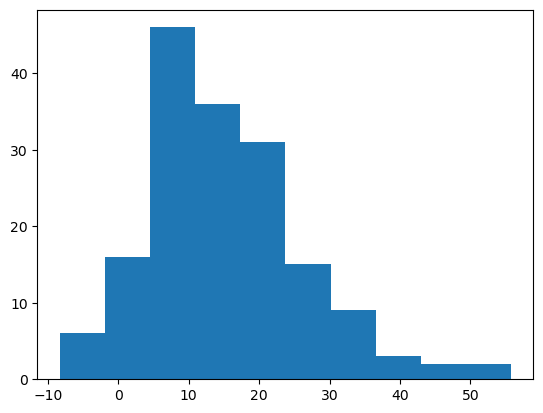

In [13]:
plt.hist(AO_metadata["pct_muscle_change"])

In [14]:
Volume_metadata = process_metadata("./Volume/Volume_metadata.RDS", 1.51)
Volume_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_22352\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,vol,FP11,male,FP11w0R,22.3,23.6,0.18,No_responder,3.0,RM10,1.51
1,vol,FP11,male,FP11w0L,22.3,23.6,-1.53,No_responder,1.0,RM10,1.51
2,vol,FP12,female,FP12w0R,21.3,22.8,-0.60,No_responder,3.0,RM10,1.51
3,vol,FP12,female,FP12w0L,21.3,22.8,0.68,No_responder,1.0,RM10,1.51
4,vol,FP13,male,FP13w0L,22.7,19.8,12.12,High_responder,3.0,RM10,1.51
5,vol,FP13,male,FP13w0R,22.7,19.8,6.72,Average_responder,1.0,RM10,1.51
6,vol,FP14,female,FP14w0R,22.1,24.1,6.45,Average_responder,3.0,RM10,1.51
7,vol,FP14,female,FP14w0L,22.1,24.1,6.16,Average_responder,1.0,RM10,1.51
8,vol,FP15,male,FP15w0R,23.6,21.1,5.26,Average_responder,3.0,RM10,1.51
9,vol,FP15,male,FP15w0L,23.6,21.1,2.68,Average_responder,1.0,RM10,1.51


<Axes: xlabel='category', ylabel='count'>

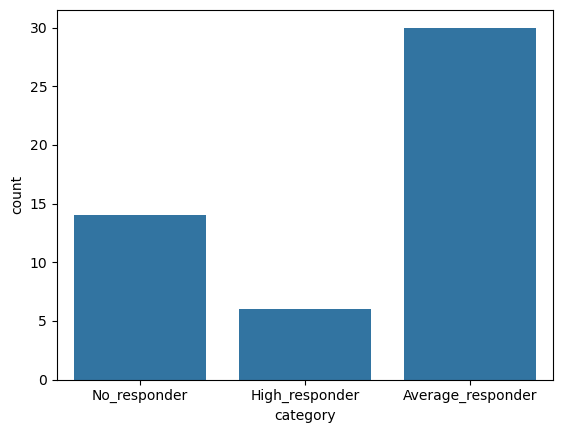

In [15]:
sns.countplot(x =Volume_metadata["category"])

(array([5., 9., 7., 5., 4., 5., 8., 3., 1., 3.]),
 array([-2.16, -0.72,  0.72,  2.16,  3.6 ,  5.04,  6.48,  7.92,  9.36,
        10.8 , 12.24]),
 <BarContainer object of 10 artists>)

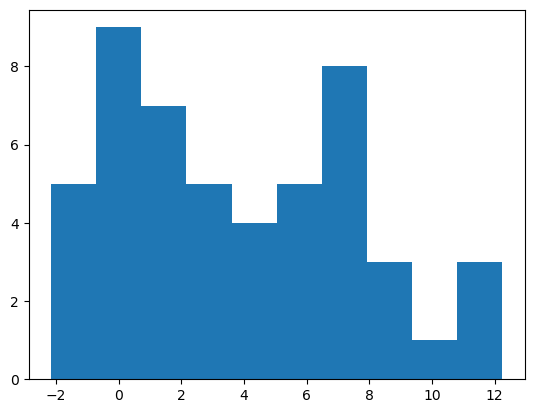

In [16]:
plt.hist(Volume_metadata["pct_muscle_change"])

In [17]:
Relief_metadata = process_metadata("./Relief/Relief_metadata.RDS", 2.33)
Relief_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_22352\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,ReLiEf,3003,male,R_8,27.0,25.9,33.45,High_responder,1.0,RM10,2.33
1,ReLiEf,3006,male,R_18,21.0,24.5,4.39,Average_responder,1.0,RM10,2.33
2,ReLiEf,3007,male,R_25,73.0,24.2,-16.01,No_responder,1.0,RM10,2.33
3,ReLiEf,3009,male,R_30,79.0,26.0,33.09,High_responder,3.0,RM10,2.33
4,ReLiEf,3009,male,R_34,79.0,26.0,3.29,Average_responder,1.0,RM10,2.33
...,...,...,...,...,...,...,...,...,...,...,...
73,ReLiEf,3075,male,R_321,81.0,22.6,8.58,Average_responder,3.0,RM10,2.33
74,ReLiEf,3079,male,R_331,23.0,28.7,23.89,Average_responder,3.0,RM10,2.33
75,ReLiEf,3083,male,R_342,72.0,29.4,18.51,Average_responder,1.0,RM10,2.33
76,ReLiEf,3084,male,R_348,80.0,20.2,-6.90,No_responder,3.0,RM10,2.33


<Axes: xlabel='category', ylabel='count'>

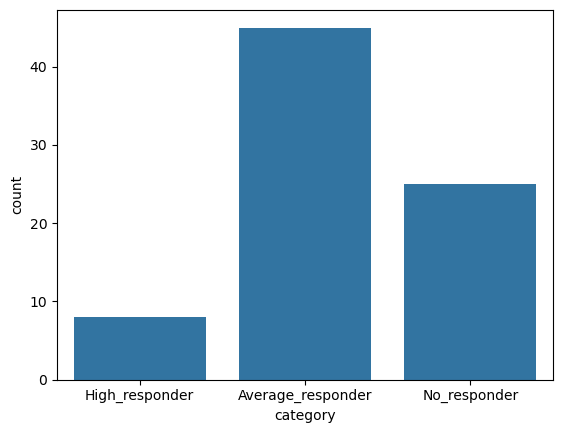

In [18]:
sns.countplot(x =Relief_metadata["category"])

(array([ 5.,  8., 16., 16., 19.,  7.,  4.,  2.,  0.,  1.]),
 array([-21.53 , -13.498,  -5.466,   2.566,  10.598,  18.63 ,  26.662,
         34.694,  42.726,  50.758,  58.79 ]),
 <BarContainer object of 10 artists>)

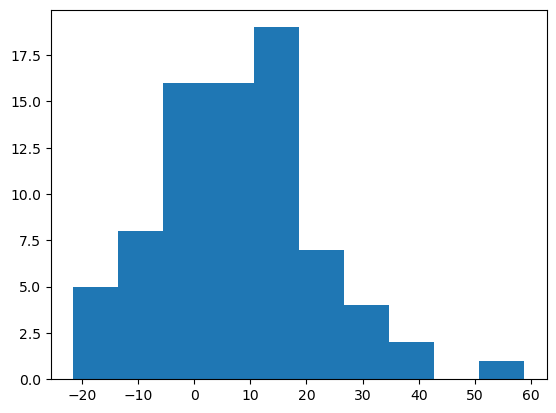

In [19]:
plt.hist(Relief_metadata["pct_muscle_change"])

In [20]:
np.percentile(Relief_metadata["pct_muscle_change"], 95)

33.144

In [21]:
# Concatenate dataset into one
full_metadata = pd.concat([AO_metadata, contratrain_metadata, copd_metadata,Relief_metadata, Volume_metadata], ignore_index = True)
# distinguish each participant from the other in different studies
full_metadata["participant"] = full_metadata["study"] + "_" + full_metadata["participant"]

full_metadata = full_metadata[["participant","seq_sample_id", "age", "BMI", "sex",   "category",  "sequencing_depth", "volume"]]
# ensure volume is integer
full_metadata["volume"] = full_metadata["volume"].astype(int)
full_metadata

,participant,seq_sample_id,age,BMI,sex,category,sequencing_depth,volume
0,Alpha/Omega_516,s104,46.0,29.0,male,Average_responder,2.35,3
1,Alpha/Omega_517,s112,53.0,30.3,male,Average_responder,2.35,3
2,Alpha/Omega_503,s13,46.0,25.3,male,High_responder,2.35,3
3,Alpha/Omega_520,s130,58.0,29.9,male,Average_responder,2.35,3
4,Alpha/Omega_521,s136,48.0,18.4,female,High_responder,2.35,3
...,...,...,...,...,...,...,...,...
456,vol_FP6,FP6w0R,21.8,20.5,female,No_responder,1.51,1
457,vol_FP7,FP7w0L,21.2,28.2,male,High_responder,1.51,3
458,vol_FP7,FP7w0R,21.2,28.2,male,High_responder,1.51,1
459,vol_FP9,FP9w0R,20.6,21.2,male,Average_responder,1.51,3


In [22]:
full_metadata["participant"].nunique()

232

In [23]:
full_metadata["participant"].valuecounts()

AttributeError: 'Series' object has no attribute 'valuecounts'

<Axes: xlabel='category', ylabel='count'>

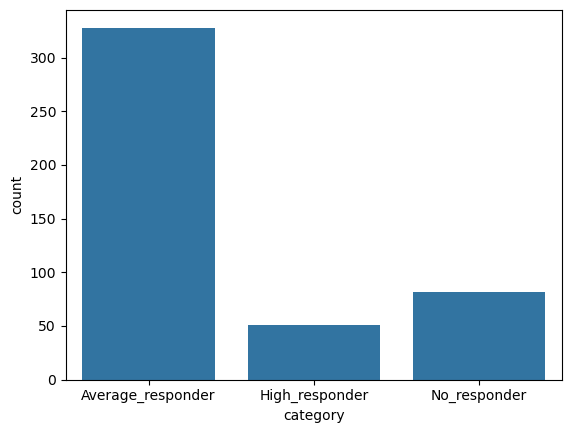

In [22]:
sns.countplot(x = full_metadata["category"])

## Load the different gene counts

In [23]:


def load_rds_dataframe(filepath):
    """
    Load a DataFrame from an RDS file using pyreadr.

    Parameters:
        filepath (str): Path to the RDS file.

    Returns:
        pd.DataFrame: The extracted DataFrame from the RDS file.
    """
    result = pyreadr.read_r(filepath)
    return result[None]

In [24]:
# Alpha_Omega data
AO_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_AO_counts.RDS")

#Contratrain data
Contratrain_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_contratrain_counts.RDS")

# COPD data
Copd_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_COPD_counts.RDS")

# Relief data
Relief_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_Relief_counts.RDS")

# Volume data
Volume_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_vol_counts.RDS")

# Merge all gene count datasets on the 'gene_name' column
datasets = [AO_genecounts, Contratrain_genecounts, Copd_genecounts, Relief_genecounts, Volume_genecounts]
full_genecounts = datasets[0]

for df in datasets[1:]:
    full_genecounts = full_genecounts.merge(df, on="gene_name")

# Reformat the merged DataFrame
full_genecounts = (
    full_genecounts
    .set_index("gene_name")
    .T
    .reset_index()
    .rename(columns={"index": "seq_sample_id"})
    .round(2)
)

full_genecounts


gene_name,seq_sample_id,TSPAN6,DPM1,SCYL3,CFH,FUCA2,GCLC,NFYA,NIPAL3,LAS1L,...,ENSG00000308270,ENSG00000309097,ENSG00000309174,ENSG00000309618,ENSG00000310376,CAST,ENSG00000310523,WASH7P,WASH9P,ENSG00000310533
0,s104,2.85,19.47,6.06,12.99,4.15,9.78,8.41,9.10,23.94,...,7.30,3.34,3.51,2.66,31.37,157.40,13.45,15.81,16.39,2.24
1,s112,4.25,19.76,6.39,19.20,5.70,17.68,10.84,9.19,17.68,...,9.82,1.52,3.50,2.66,15.78,184.27,12.59,30.12,23.76,3.25
2,s13,2.46,18.50,5.84,12.23,4.67,8.91,8.73,7.18,19.02,...,5.97,1.30,1.52,1.69,59.18,112.53,19.85,32.41,32.34,2.70
3,s130,2.30,16.77,8.36,15.13,3.07,8.56,9.33,5.08,25.74,...,2.42,1.83,6.24,3.66,50.90,174.12,23.37,32.45,29.37,2.70
4,s136,3.71,20.30,7.15,17.74,5.68,11.86,9.21,3.46,21.19,...,5.56,2.10,2.97,4.39,40.53,179.86,12.12,17.64,16.53,3.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,FP6w0R,6.57,30.72,8.41,22.26,4.81,12.66,11.25,14.89,22.27,...,13.60,2.58,4.64,7.15,675.39,143.34,3.45,5.61,4.61,4.41
284,FP7w0L,3.76,34.44,7.34,17.47,3.76,11.28,8.33,11.15,20.82,...,26.73,5.24,1.66,7.79,754.49,157.02,2.54,6.38,3.99,2.55
285,FP7w0R,4.51,33.87,5.79,18.75,3.78,10.84,7.31,10.97,20.96,...,22.30,4.51,2.79,7.19,721.26,156.08,5.11,10.87,5.40,1.82
286,FP9w0R,4.12,34.01,7.86,11.90,4.74,7.73,9.61,9.61,25.82,...,33.06,3.87,0.98,10.73,710.98,178.77,7.24,13.17,8.82,1.94


Merge the genes and metadata into one dataframe and encode the sex column as a dummy variable

In [25]:
# join the gene expression data and the metadata
df = ( full_metadata.merge(full_genecounts, on = "seq_sample_id")
       .sort_values(by = "seq_sample_id")
     )
df = pd.get_dummies(df, columns = ["sex"], dtype=int) # create dummy variable
df

,seq_sample_id,age,BMI,category,sequencing_depth,volume,TSPAN6,DPM1,SCYL3,CFH,...,ENSG00000309174,ENSG00000309618,ENSG00000310376,CAST,ENSG00000310523,WASH7P,WASH9P,ENSG00000310533,sex_female,sex_male
412,FP11w0L,22.3,23.6,No_responder,1.51,1,3.85,30.23,8.50,15.33,...,2.95,5.89,1125.84,230.96,5.93,11.60,5.07,1.88,0,1
411,FP11w0R,22.3,23.6,No_responder,1.51,3,4.72,27.63,9.59,19.16,...,3.75,4.72,1057.75,243.95,5.91,11.36,3.96,2.30,0,1
414,FP12w0L,21.3,22.8,No_responder,1.51,1,5.48,32.51,6.23,15.13,...,2.91,7.09,614.65,143.06,7.21,7.53,7.33,2.78,1,0
413,FP12w0R,21.3,22.8,No_responder,1.51,3,5.88,28.35,5.72,16.30,...,2.41,10.94,584.76,142.61,7.23,15.26,9.02,1.10,1,0
415,FP13w0L,22.7,19.8,High_responder,1.51,3,5.59,34.57,4.74,9.17,...,2.29,6.95,724.77,158.42,3.87,16.90,13.56,5.87,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,s891,54.0,21.8,Average_responder,2.35,3,3.94,18.93,7.06,10.28,...,4.78,1.79,12.13,131.02,17.86,29.32,28.00,3.93,1,0
165,s903,42.0,27.3,High_responder,2.35,3,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
81,s903,42.0,27.3,Average_responder,2.35,3,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
82,s96,48.0,27.7,Average_responder,2.35,3,4.69,25.65,7.67,13.27,...,1.94,1.73,37.61,151.40,15.83,24.10,27.72,3.25,0,1


In [26]:
# How many of each responder category is present in the dataset
df["category"].value_counts()

category
Average_responder    328
No_responder          82
High_responder        51
Name: count, dtype: int64

In [27]:
df.to_csv("./dataset_for_classification_model.csv", index = False)

 Create the predictor and response varaibles

In [28]:
X = df.drop(["seq_sample_id", "category"], axis = 1) # drop sample_id and category columns

y = df["category"] # response variable
category_mapping = {'No_responder': 0, 'Average_responder': 1, 'High_responder': 2} # label encode the variables
y = y.map(category_mapping)
y

412    0
411    0
414    0
413    0
415    2
      ..
164    1
165    2
81     1
82     1
91     1
Name: category, Length: 461, dtype: int64

## data splitting and scaling

In [29]:
# create the final test set (20% of data) which we won't touch until the very end.
X_train_full, X_test, y_train_full, y_test = train_test_split( X, y,  test_size=0.2, random_state=RANDOM_STATE, stratify = y)
# "stratify" ensures that the data distribution is maintained

# Create a validation set (20% of the remaining training data) for monitoring during training.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,  test_size=0.2, random_state=RANDOM_STATE, stratify = y_train_full
)


#  scale the data. Fit the scaler ONLY on the training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training feature shape: {X_train_scaled.shape}")
print(f"Validation feature shape: {X_val_scaled.shape}")
print(f"Test feature shape: {X_test_scaled.shape}")

Training feature shape: (294, 11231)
Validation feature shape: (74, 11231)
Test feature shape: (93, 11231)


Model trained on the raw data performed poorly when predicting the high and no responders, hence the decision to use SMOTE (Synthetic Minority Over-sampling Technique) to address the imbalance. SMOTE was applied  on training sample alone so as not to force a perfect balance in the dataset  (to reduce overfitting). The minority classes (high_responders, and no_responders) were oversampled to 80% of average responders

In [30]:
# Inspect class distribution on training data
classes, counts = np.unique(y_train, return_counts=True)
print("Train class counts:", dict(zip(classes, counts)))

# Target "soft" balancing: bring minorities up to ~80% of the majority in the training split
majority_count = counts.max()
target_level = int(0.8 * majority_count)

# Build a dict for sampling_strategy for multiclass
sampling_strategy = {int(c): min(target_level, int(majority_count)) for c in classes}
# oversample minorities that are below target_level
for c, cnt in zip(classes, counts):
    if cnt >= target_level:
        sampling_strategy[int(c)] = cnt  # keep as is

# k_neighbors must be < minority count; pick conservatively
min_class_count = counts.min()
k_neighbors = max(1, min(5, min_class_count - 1))

print("SMOTE sampling_strategy:", sampling_strategy)
print("SMOTE k_neighbors:", k_neighbors)

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    k_neighbors=k_neighbors,
    random_state=42,
    n_jobs=-1
)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print("After SMOTE:", {int(c): int(n) for c, n in zip(*np.unique(y_train_sm, return_counts=True))})


Train class counts: {0: 52, 1: 209, 2: 33}
SMOTE sampling_strategy: {0: 167, 1: 209, 2: 167}
SMOTE k_neighbors: 5


C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


After SMOTE: {0: 167, 1: 209, 2: 167}


Text(0, 0.5, 'Frequency')

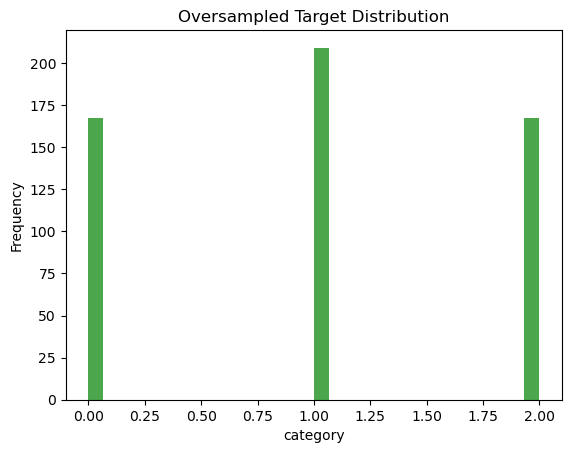

In [31]:
# Step 4: Visualize class distribution after SMOTE
plt.hist(y_train_sm, bins=30, color='green', alpha=0.7)
plt.title('Oversampled Target Distribution')
plt.xlabel('category')
plt.ylabel('Frequency')

## Model building


In [42]:

def build_multiclass_model(input_shape, num_classes):
    """Builds a sequential model for multi-class classification."""
    model = Sequential([
        Input(shape=input_shape),
 # Hidden Layer 1: Funnel architecture starts wider. L2 regularization added.
      
   #    Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.00001)),
   #     Dropout(0.4), # Using a slightly higher dropout rate
        
        
        # Hidden Layer 2
        Dense(512, kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(), Activation('relu'),
        Dropout(0.4), # Using a slightly higher dropout rate

        
        # Hidden Layer 3
       Dense(256,  kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(), Activation('relu'),
       Dropout(0.3),

        # Hidden Layer 4
        Dense(128,  kernel_regularizer=regularizers.l2(1e-4)),
         Activation('relu'),
        Dropout(0.2),
        
         # Hidden Layer 5
        Dense(64,  kernel_regularizer=regularizers.l2(5e-5)),
         Activation('relu'),
        Dense(num_classes, activation='softmax')  # Multi-class classification
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),  # cos labels are encoded as integers
                  metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")])
    
    return model


In [43]:
# Get the input shape from the training data
input_shape = (X_train_sm.shape[1],)
model = build_multiclass_model(input_shape, 3)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 512)                 │       5,750,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_13 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_14 (Activation)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,926,531 (22.61 MB)

 Trainable params: 5,924,995 (22.60 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [273]:
# --- Step 4: Train the Model with Advanced Callbacks ---
print("\nStep 4: Training the Model...")

# EarlyStopping to prevent overfitting by stopping when validation loss stops improving.
early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience=15,          # How many epochs to wait after last improvement
    restore_best_weights=True # Restores model weights from the epoch with the best val_loss
)

# ReduceLROnPlateau to reduce the learning rate when a metric has stopped improving.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=3,           # Number of epochs with no improvement after which learning rate will be reduced.
    min_lr=1e-6           # Lower bound on the learning rate.
)

ckpt = ModelCheckpoint(
    "best_model.keras", monitor="val_loss", save_best_only=True, verbose=1
)

history = model.fit(
    X_train_sm, y_train_sm,
    epochs=200, # Train for more epochs; EarlyStopping will handle stopping.
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping, reduce_lr, ckpt],
    verbose=1 # Set to 1 to see training progress
)




Step 4: Training the Model...
Epoch 1/200
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3380 - loss: 1.8887
Epoch 1: val_loss improved from inf to 1.78144, saving model to best_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.3422 - loss: 1.8622 - val_accuracy: 0.2297 - val_loss: 1.7814 - learning_rate: 1.0000e-04
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4677 - loss: 1.2547
Epoch 2: val_loss improved from 1.78144 to 1.19455, saving model to best_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.4684 - loss: 1.2537 - val_accuracy: 0.5405 - val_loss: 1.1945 - learning_rate: 1.0000e-04
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5145 - loss: 1.1679
Epoch 3: val_loss improved from 1.19455 to 1.09309, saving model to best_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5170 - loss: 1.1633 - val_accuracy: 0.6081 - val_loss: 1.0931 - learning_rate: 1.0000e-04
Epoch 4/200
17/17 ━━━━━━━━━━

In [274]:
# --- Step 5: Evaluate the Final Model ---
print("\nStep 5: Evaluating the Final Model on the Test Set...")

# Evaluate the model on the unseen test set to get a final, unbiased performance metric.
final_loss, final_mae = model.evaluate(X_test_scaled, y_test)
print(f"Final  loss: {final_loss:.4f}")
print(f"Final Test accuracy: {final_mae:.4f}")



Step 5: Evaluating the Final Model on the Test Set...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6424 - loss: 1.0840
Final  loss: 1.1239
Final Test accuracy: 0.6129


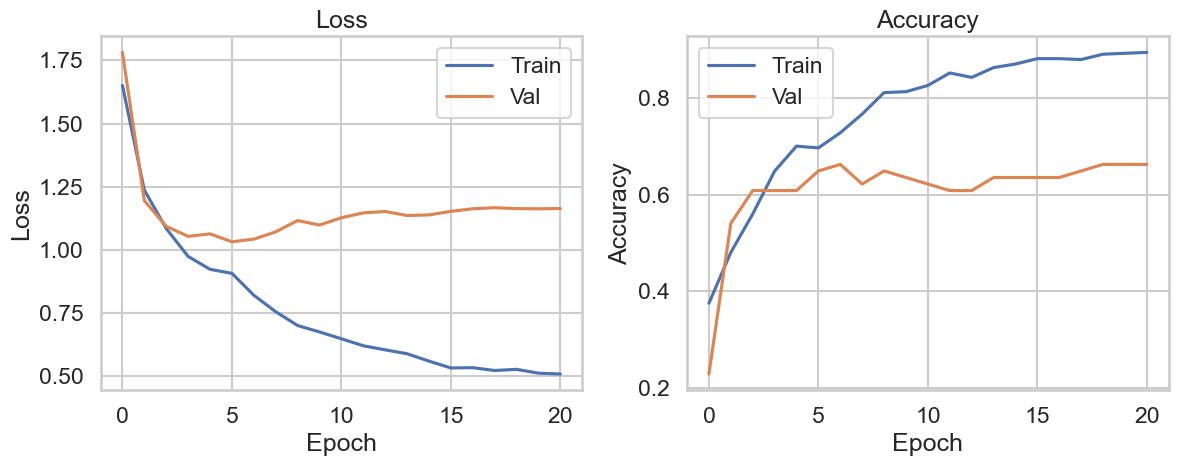

In [275]:
# --- Step 5: Metrics & Visualizations (Keras + SMOTE workflow) ---


sns.set(style="whitegrid", context="talk")

# Recover readable class names in the correct order (0,1,2) from your mapping
category_mapping = {'No_responder': 0, 'Average_responder': 1, 'High_responder': 2}
inv_map = {v: k for k, v in category_mapping.items()}
class_names = [inv_map[i] for i in range(len(inv_map))]  # ['No_responder','Average_responder','High_responder']

# ---- 5A) Training curves (loss & accuracy) ----
hist_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Loss
ax[0].plot(hist_df['loss'], label='Train')
if 'val_loss' in hist_df:
    ax[0].plot(hist_df['val_loss'], label='Val')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy
if 'accuracy' in hist_df:
    ax[1].plot(hist_df['accuracy'], label='Train')
if 'val_accuracy' in hist_df:
    ax[1].plot(hist_df['val_accuracy'], label='Val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.tight_layout()
plt.show()

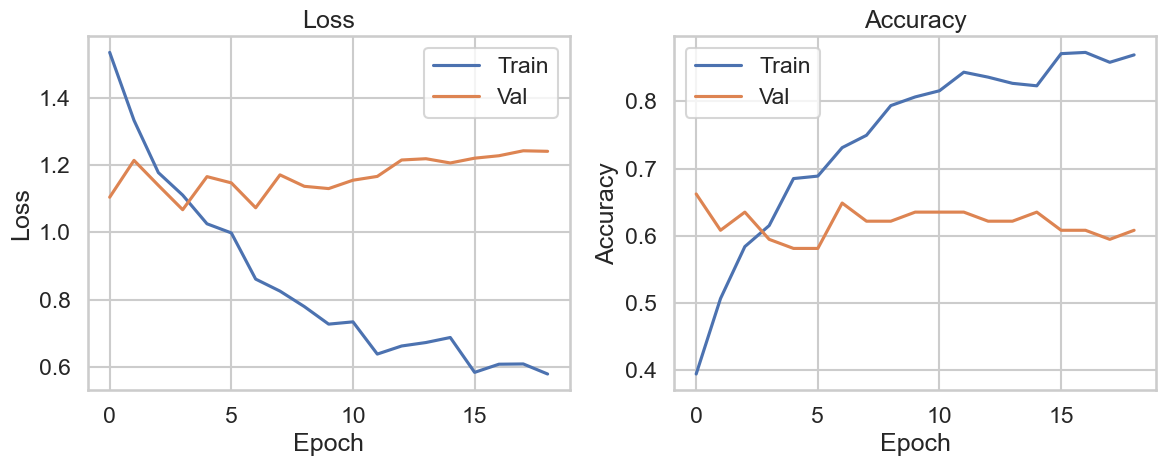


=== Validation Metrics ===
Accuracy:            0.595
Macro-F1:            0.408
Balanced Accuracy:   0.406
Macro ROC-AUC (OVR): 0.671

Classification report:
                   precision    recall  f1-score   support

     No_responder      0.214     0.231     0.222        13
Average_responder      0.736     0.736     0.736        53
   High_responder      0.286     0.250     0.267         8

         accuracy                          0.595        74
        macro avg      0.412     0.406     0.408        74
     weighted avg      0.596     0.595     0.595        74



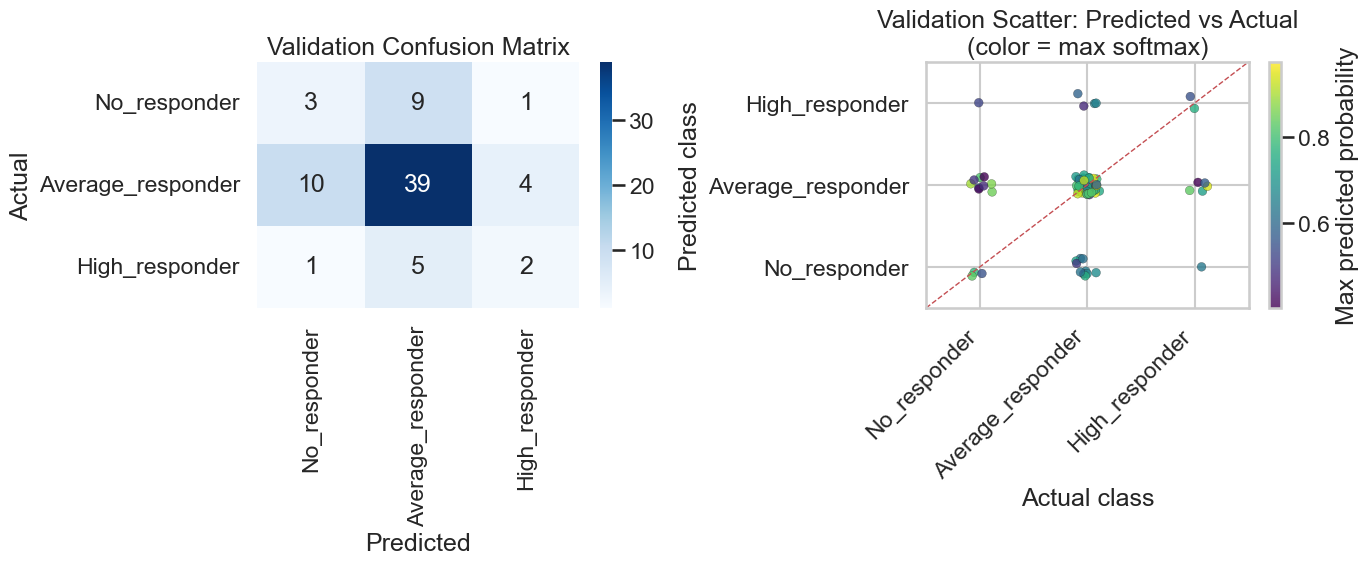

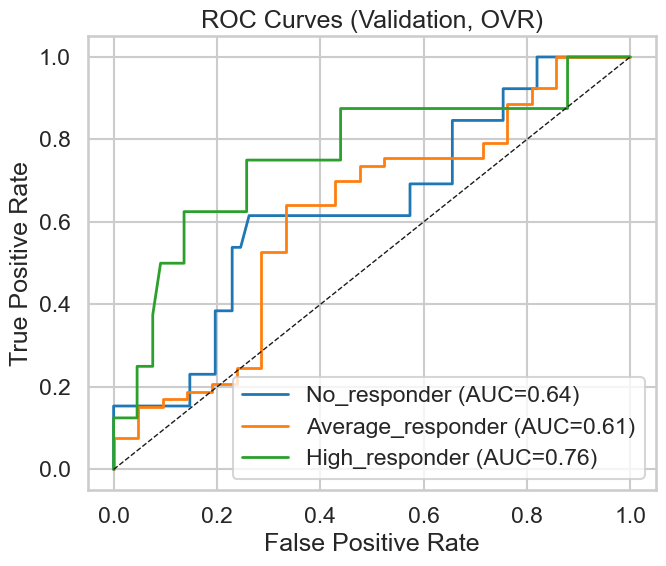

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_6264\2447839076.py:121: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


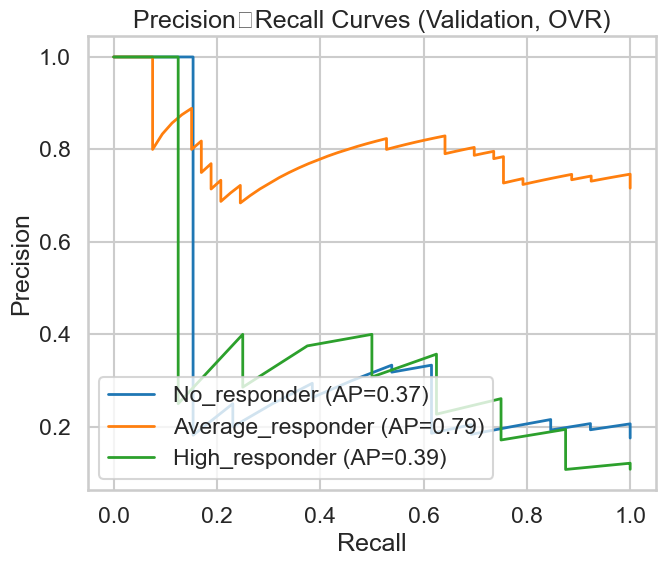


=== Test Metrics ===
Accuracy:            0.581
Macro-F1:            0.425
Balanced Accuracy:   0.431
Macro ROC-AUC (OVR): 0.641

Classification report:
                   precision    recall  f1-score   support

     No_responder      0.304     0.412     0.350        17
Average_responder      0.726     0.682     0.703        66
   High_responder      0.250     0.200     0.222        10

         accuracy                          0.581        93
        macro avg      0.427     0.431     0.425        93
     weighted avg      0.598     0.581     0.587        93



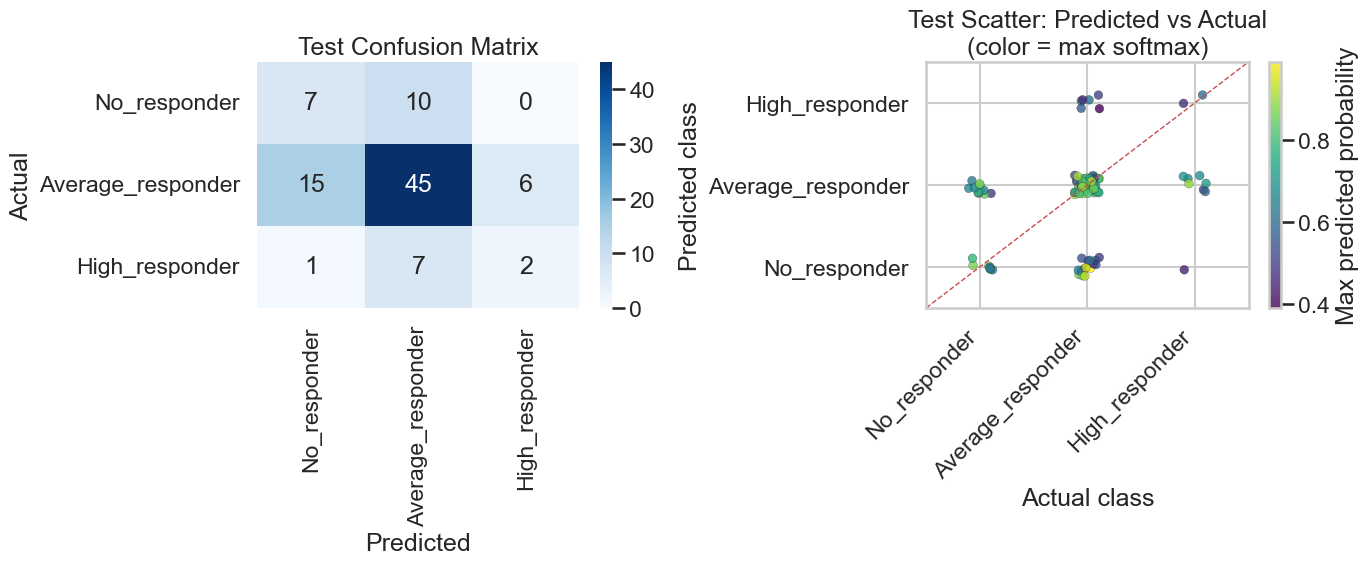

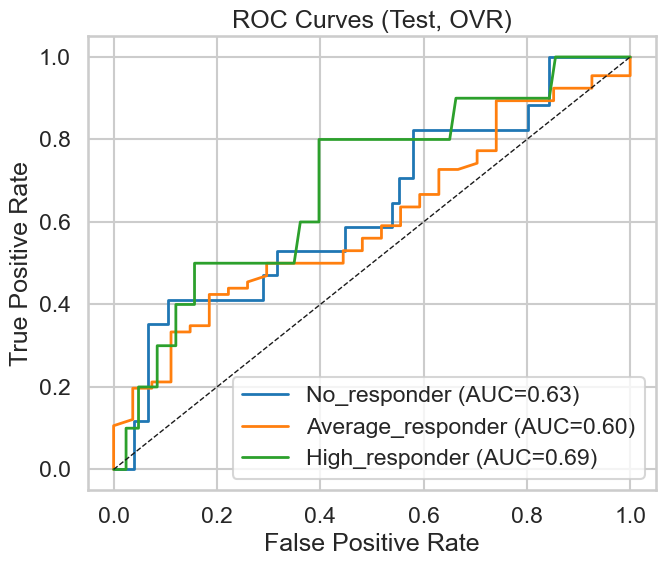

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_6264\2447839076.py:121: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


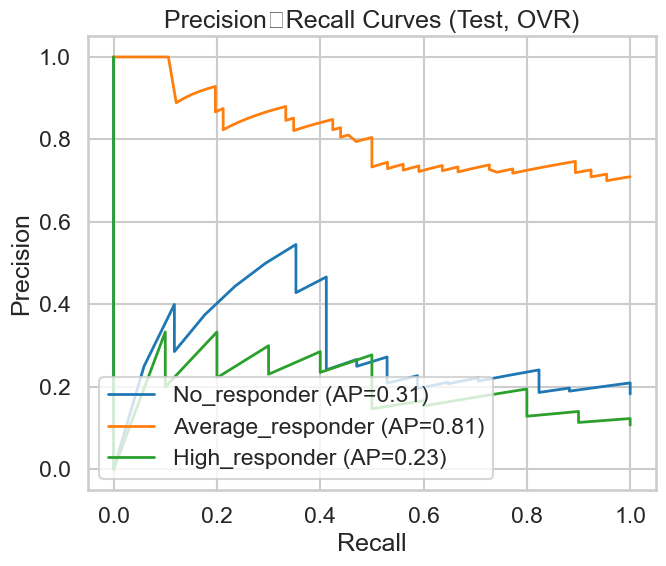

In [257]:
# --- Step 5: Metrics & Visualizations (Keras + SMOTE workflow) ---


sns.set(style="whitegrid", context="talk")


# Recover readable class names in the correct order (0,1,2) from your mapping
category_mapping = {'No_responder': 0, 'Average_responder': 1, 'High_responder': 2}
inv_map = {v: k for k, v in category_mapping.items()}
class_names = [inv_map[i] for i in range(len(inv_map))]  # ['No_responder','Average_responder','High_responder']

# ---- 5A) Training curves (loss & accuracy) ----
hist_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Loss
ax[0].plot(hist_df['loss'], label='Train')
if 'val_loss' in hist_df:
    ax[0].plot(hist_df['val_loss'], label='Val')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy
if 'accuracy' in hist_df:
    ax[1].plot(hist_df['accuracy'], label='Train')
if 'val_accuracy' in hist_df:
    ax[1].plot(hist_df['val_accuracy'], label='Val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.tight_layout()
plt.show()

# ---- Helper: evaluate & visualize any split ----
def evaluate_and_visualize_split(name, X_split, y_split, class_names, plot_roc_pr=True, save_figs=False, prefix=""):
    """
    name: 'Validation' or 'Test'
    X_split: scaled features
    y_split: integer labels (0..C-1)
    """
    proba = model.predict(X_split, verbose=0)           # (n, C)
    y_pred = np.argmax(proba, axis=1)
    conf   = proba.max(axis=1)                          # max softmax as confidence
    C      = proba.shape[1]

    # --- Metrics ---
    acc  = accuracy_score(y_split, y_pred)
    f1m  = f1_score(y_split, y_pred, average='macro', zero_division=0)
    bacc = balanced_accuracy_score(y_split, y_pred)
    try:
        aucm = roc_auc_score(y_split, proba, multi_class='ovr', average='macro')
    except Exception:
        aucm = np.nan

    print(f"\n=== {name} Metrics ===")
    print(f"Accuracy:            {acc:.3f}")
    print(f"Macro-F1:            {f1m:.3f}")
    print(f"Balanced Accuracy:   {bacc:.3f}")
    print(f"Macro ROC-AUC (OVR): {aucm:.3f}")
    print("\nClassification report:")
    print(classification_report(y_split, y_pred, target_names=class_names, digits=3, zero_division=0))

    # --- Confusion matrix (counts) ---
    cm = confusion_matrix(y_split, y_pred, labels=np.arange(C))

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax[0])
    ax[0].set_title(f'{name} Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # --- Predicted vs Actual scatter with jitter (color = confidence) ---
    jitter = 0.12
    x_j = y_split + np.random.uniform(-jitter, jitter, size=y_split.shape)
    y_j = y_pred  + np.random.uniform(-jitter, jitter, size=y_pred.shape)

    sc = ax[1].scatter(x_j, y_j, c=conf, cmap='viridis', s=40, alpha=0.8, edgecolor='k', linewidth=0.2)
    ax[1].plot([-0.5, C-0.5], [-0.5, C-0.5], 'r--', lw=1)  # perfect predictions diagonal
    ax[1].set_xticks(range(C)); ax[1].set_yticks(range(C))
    ax[1].set_xticklabels(class_names, rotation=45, ha='right'); ax[1].set_yticklabels(class_names)
    ax[1].set_xlim([-0.5, C-0.5]); ax[1].set_ylim([-0.5, C-0.5])
    ax[1].set_title(f'{name} Scatter: Predicted vs Actual\n(color = max softmax)')
    ax[1].set_xlabel('Actual class'); ax[1].set_ylabel('Predicted class')
    cbar = plt.colorbar(sc, ax=ax[1]); cbar.set_label('Max predicted probability')
    plt.tight_layout()
    if save_figs:
        plt.savefig(f"{prefix}{name.lower()}_confusion_and_scatter.png", dpi=200, bbox_inches='tight')
    plt.show()

    # --- Optional: ROC & Precision-Recall curves (one-vs-rest) ---
    if plot_roc_pr:
        try:
            y_bin = label_binarize(y_split, classes=np.arange(C))

            # ROC curves
            from itertools import cycle
            colors = cycle(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])
            fig, ax = plt.subplots(figsize=(7, 6))
            for i, color in zip(range(C), colors):
                fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, color=color, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.2f})")
            ax.plot([0,1],[0,1], 'k--', lw=1)
            ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title=f"ROC Curves ({name}, OVR)")
            ax.legend(loc="lower right")
            plt.tight_layout()
            if save_figs:
                plt.savefig(f"{prefix}{name.lower()}_roc_curves.png", dpi=200, bbox_inches='tight')
            plt.show()

            # Precision-Recall curves
            colors = cycle(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])
            fig, ax = plt.subplots(figsize=(7, 6))
            for i, color in zip(range(C), colors):
                precision, recall, _ = precision_recall_curve(y_bin[:, i], proba[:, i])
                ap = average_precision_score(y_bin[:, i], proba[:, i])
                ax.plot(recall, precision, color=color, lw=2, label=f"{class_names[i]} (AP={ap:.2f})")
            ax.set(xlabel="Recall", ylabel="Precision", title=f"Precision‑Recall Curves ({name}, OVR)")
            ax.legend(loc="lower left")
            plt.tight_layout()
            if save_figs:
                plt.savefig(f"{prefix}{name.lower()}_pr_curves.png", dpi=200, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f"(ROC/PR plotting skipped: {e})")

# ---- 5B) Run on Validation ----
evaluate_and_visualize_split("Validation", X_val_scaled, y_val, class_names, plot_roc_pr=True, save_figs=False)

# ---- 5C) Run on Test (if defined) ----
evaluate_and_visualize_split("Test", X_test_scaled, y_test, class_names, plot_roc_pr=True, save_figs=False)


In [ ]:
# shap
# !pip install shap --upgrade
import shap, numpy as np, matplotlib.pyplot as plt
import pandas as pd

# Feature names (nice plots if X is a DataFrame)
feature_names = X.columns.tolist() if hasattr(X, 'columns') else [f"f{i}" for i in range(X_train_sm.shape[1])]

# Background/sample sets
rng = np.random.default_rng(42)
bg_idx  = rng.choice(X_train_sm.shape[0], size=min(200, X_train_sm.shape[0]), replace=False)
val_idx = rng.choice(X_val_scaled.shape[0], size=min(500, X_val_scaled.shape[0]), replace=False)
background   = X_train_sm[bg_idx]
X_val_sample = X_val_scaled[val_idx]

# Probability predictor
predict_fn = lambda x: model.predict(x, verbose=0)

# Try Deep/Gradient, else fallback
try:
    explainer = shap.DeepExplainer(model, background)
    _ = explainer.shap_values(background[:1])
    shap_values = explainer(X_val_sample)
except Exception:
    try:
        explainer = shap.GradientExplainer((model, model.layers[0].input), background)
        shap_values = explainer(X_val_sample)
    except Exception:
        explainer = shap.Explainer(predict_fn, background)
        shap_values = explainer(X_val_sample)

# Multiclass: loop classes
n_classes = 3
for c in range(n_classes):
    try:
        sv = shap_values[..., c]  # new API
    except Exception:
        sv = shap_values[c]       # old API

    shap.summary_plot(sv, X_val_sample, feature_names=feature_names, show=False)
    plt.title(f"SHAP Summary – Class {c}")
    plt.savefig(f"shap_summary_class{c}.png", dpi=200, bbox_inches="tight"); plt.close()

    shap.summary_plot(sv, X_val_sample, feature_names=feature_names, plot_type="bar", show=False)
    plt.title(f"SHAP Global Importance (Bar) – Class {c}")
    plt.savefig(f"shap_bar_class{c}.png", dpi=200, bbox_inches="tight"); plt.close()

# Local explanation for a sample
i = 0
try:
    shap.plots.waterfall(shap_values[i], show=False)
    plt.title("SHAP Waterfall – Sample 0")
    plt.savefig("shap_waterfall_sample0.png", dpi=200, bbox_inches="tight"); plt.close()
except Exception:
    pass

# Assuming you already computed shap_values on a val sample
minor_idx = np.where(y_val == 2)[0]  # e.g., class 2 as minority
minor_idx = minor_idx[:min(200, len(minor_idx))]

# For multiclass, pick the SHAP values for class 2
sv_c2 = shap_values[..., 2] if hasattr(shap_values, 'values') else shap_values[2]

shap.summary_plot(sv_c2[minor_idx], X_val_scaled[minor_idx],
                  feature_names=getattr(X, 'columns', None), show=True)
